# Medical Insurance Cost Prediction
### Devesh Pachchigar — End-to-End ML Project

---

# Task 1 — Import Libraries & Load Dataset

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, BaggingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import pickle
import warnings
warnings.filterwarnings('ignore')

In [8]:
df = pd.read_csv('Health_Insurance.csv')

In [9]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [11]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# Task 2 — Exploratory Data Analysis (EDA)

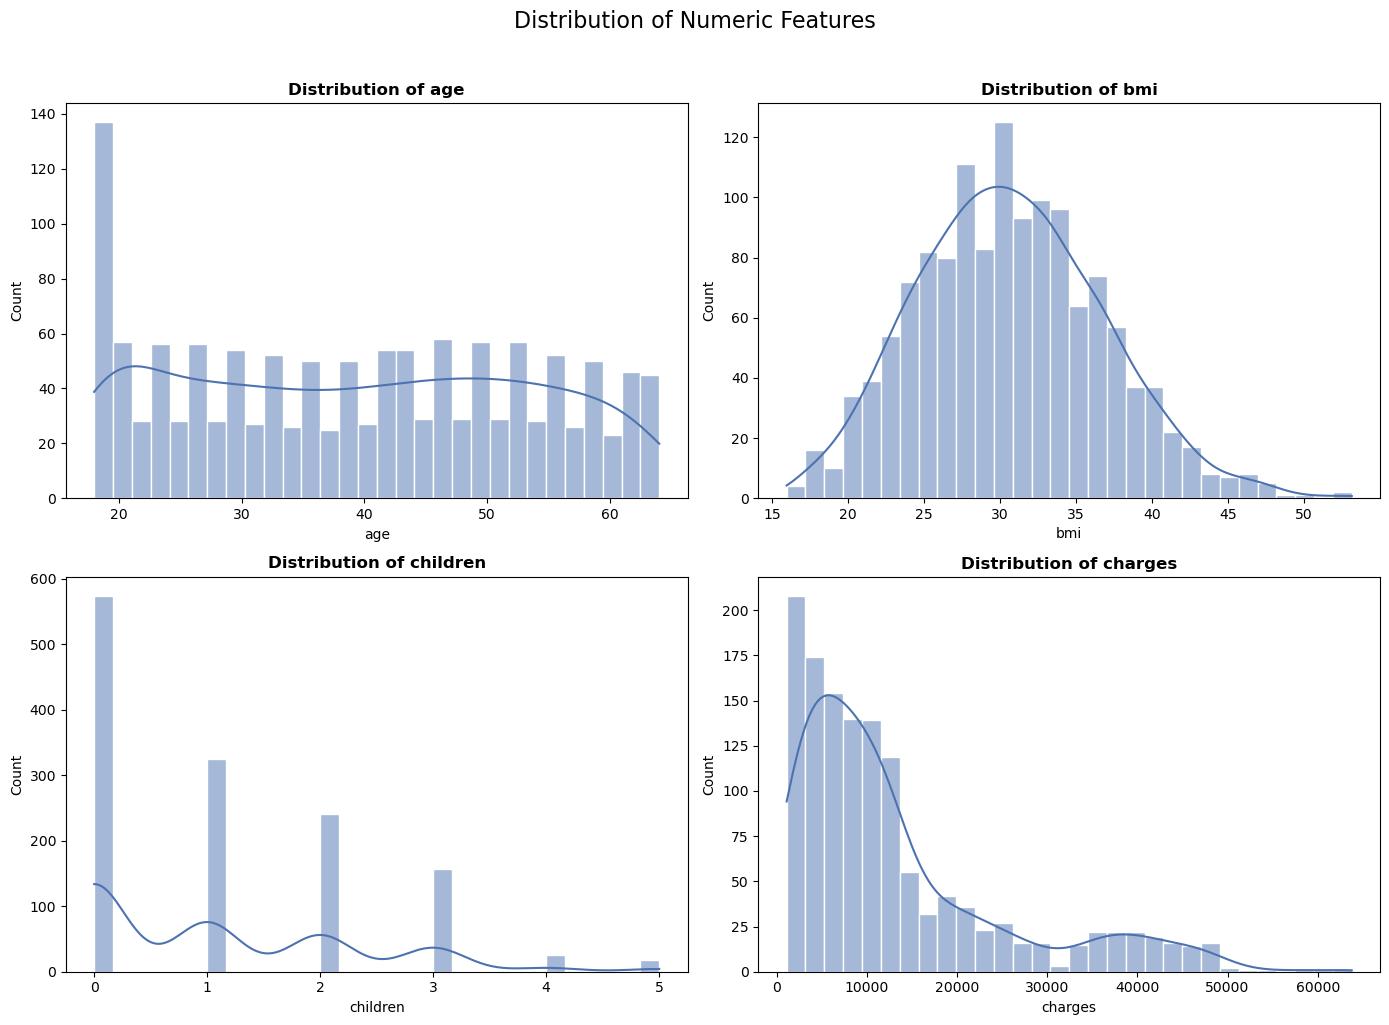

In [12]:
# distribution of numeric features
num_cols = ['age', 'bmi', 'children', 'charges']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='#4C72B0', edgecolor='white', bins=30)
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

fig.suptitle('Distribution of Numeric Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

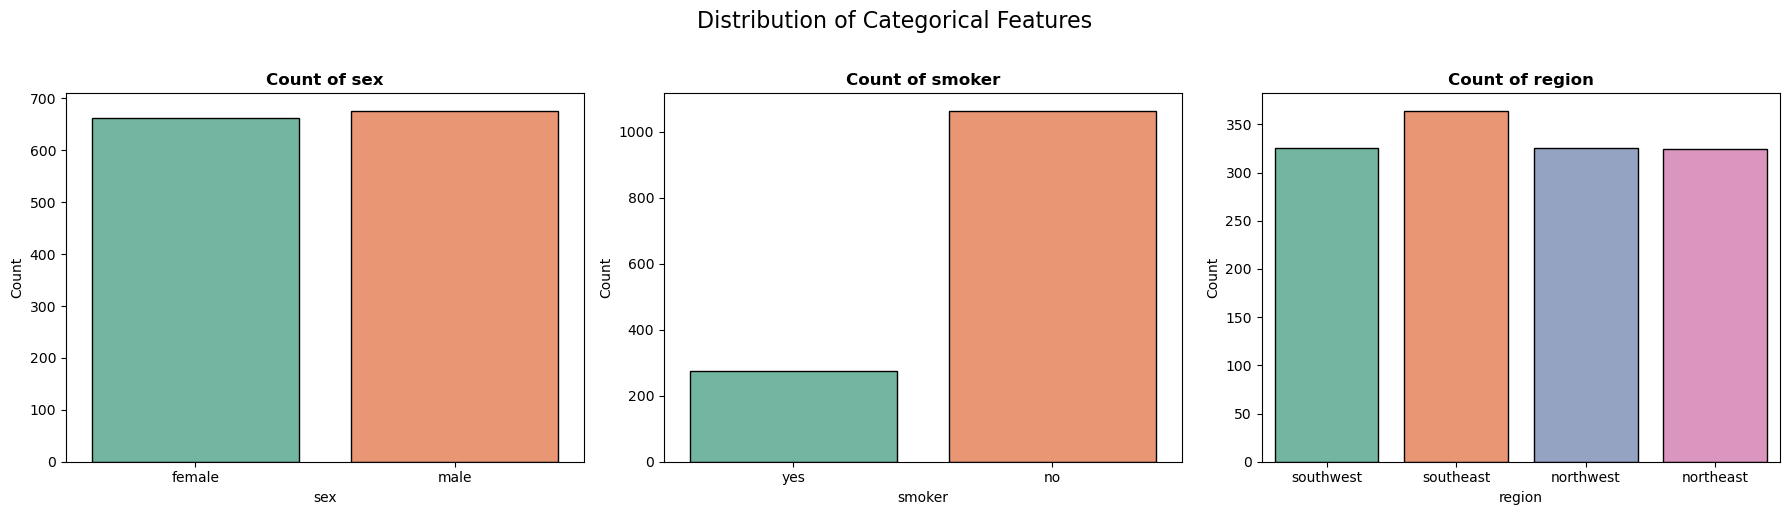

In [13]:
# distribution of categorical features
cat_cols = ['sex', 'smoker', 'region']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    sns.countplot(x=df[col], ax=ax, palette='Set2', edgecolor='black')
    ax.set_title(f'Count of {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
fig.suptitle('Distribution of Categorical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

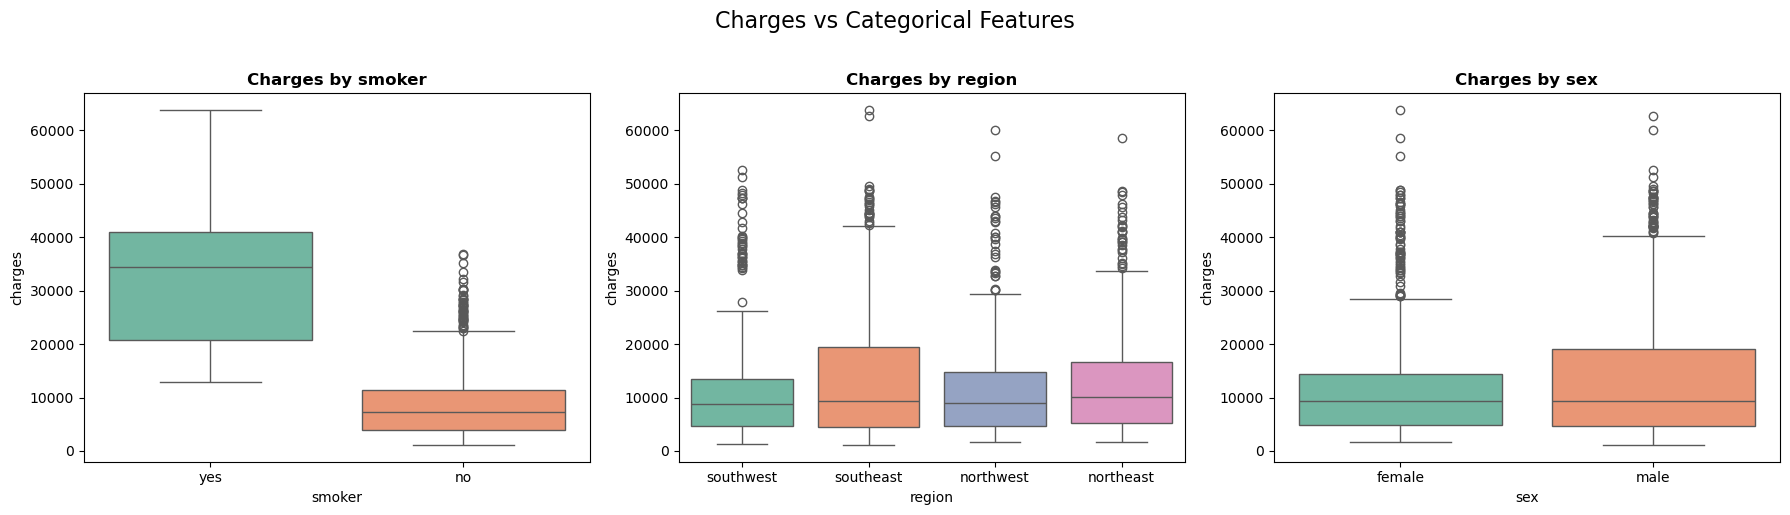

In [14]:
# charges vs categorical features — box plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['smoker', 'region', 'sex']):
    sns.boxplot(x=col, y='charges', data=df, ax=ax, palette='Set2')
    ax.set_title(f'Charges by {col}', fontweight='bold')
fig.suptitle('Charges vs Categorical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

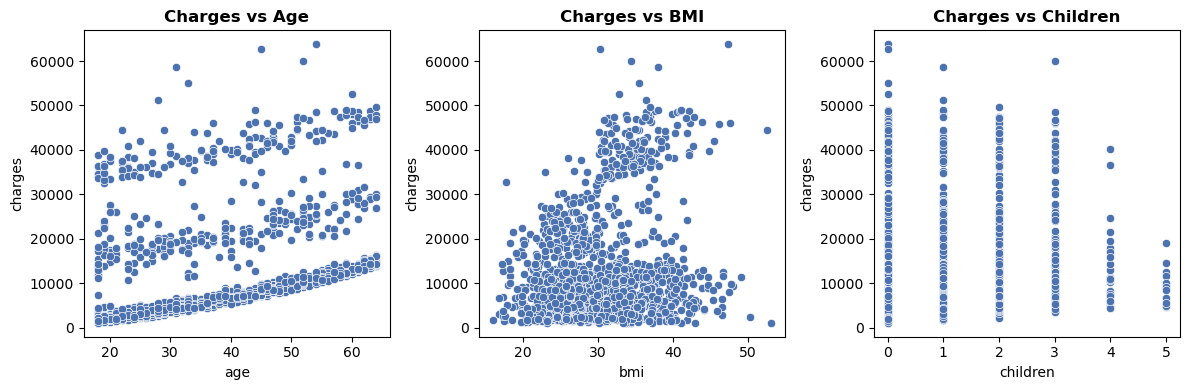

In [15]:
# scatter plots — numeric features vs charges
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.scatterplot(x='age', y='charges', data=df, color='#4C72B0', edgecolor='white')
plt.title('Charges vs Age', fontweight='bold')
plt.subplot(1, 3, 2)
sns.scatterplot(x='bmi', y='charges', data=df, color='#4C72B0', edgecolor='white')
plt.title('Charges vs BMI', fontweight='bold')
plt.subplot(1, 3, 3)
sns.scatterplot(x='children', y='charges', data=df, color='#4C72B0', edgecolor='white')
plt.title('Charges vs Children', fontweight='bold')
plt.tight_layout()
plt.show()

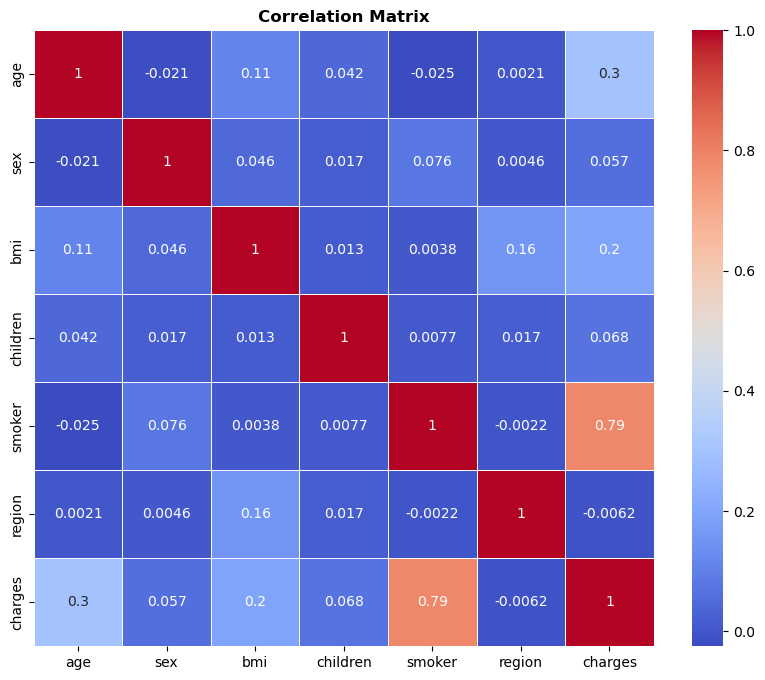

In [16]:
# correlation heatmap
le = LabelEncoder()
df_encoded = df.copy()
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(df_encoded[col])
corr_matrix = df_encoded.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix', fontweight='bold')
plt.show()

In [17]:
# EDA Summary
# Smoker status has the strongest correlation with charges — smokers pay ~4× more
# Age and BMI have a moderate positive correlation with charges
# Children and region have very low impact on charges

# Task 3 — Missing Values & Outlier Treatment

In [18]:
# check for missing values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

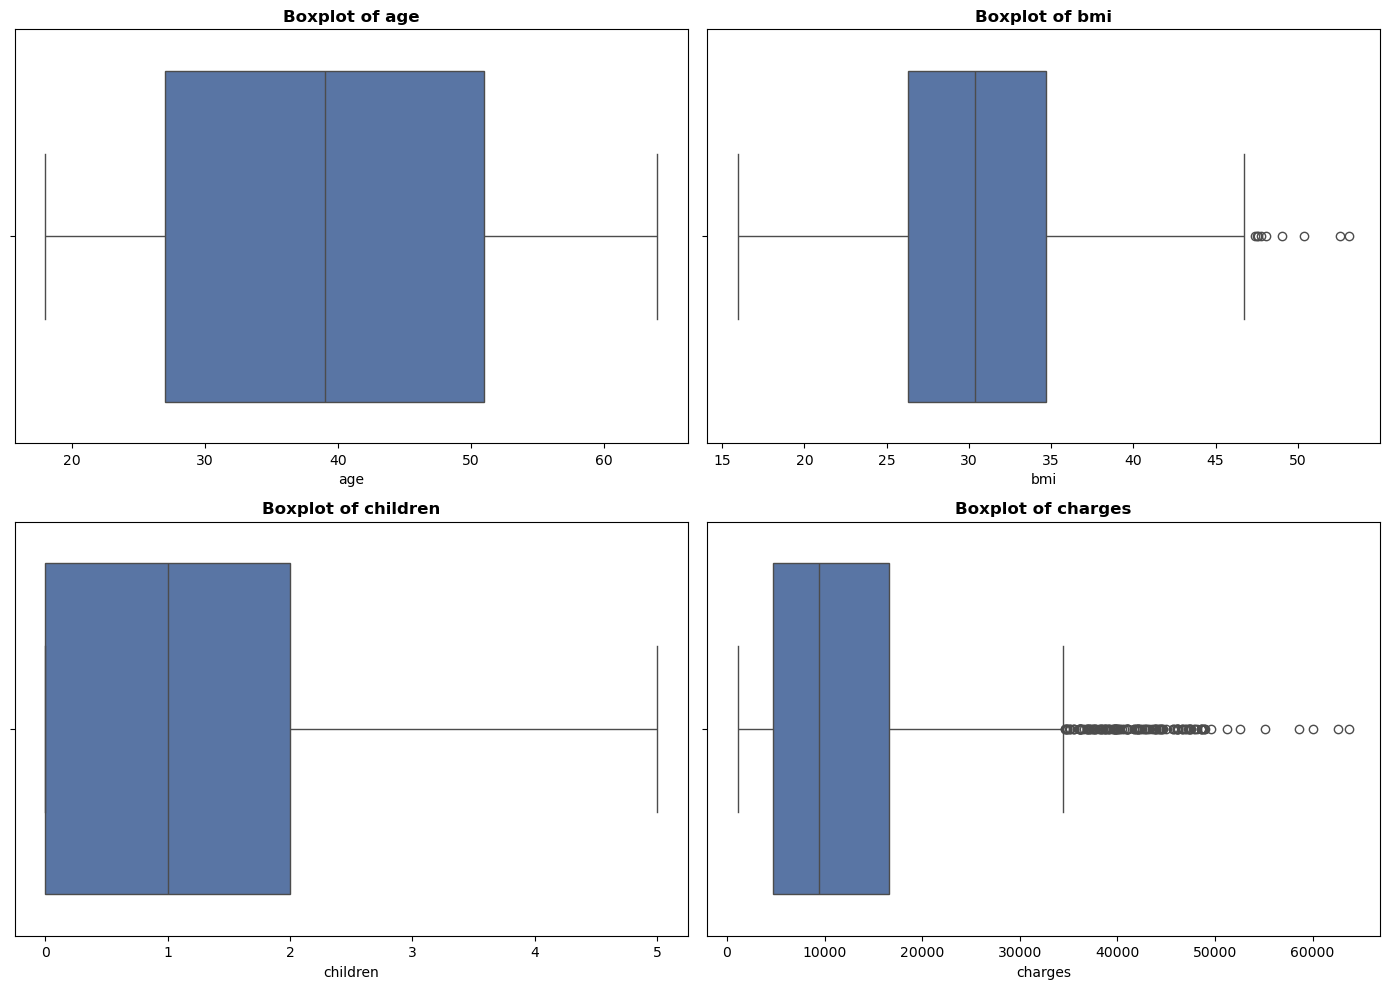

In [19]:
# check for outliers using boxplots
num_cols = ['age', 'bmi', 'children', 'charges']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, col in zip(axes, num_cols):
    sns.boxplot(x=df[col], ax=ax, color='#4C72B0')
    ax.set_title(f'Boxplot of {col}', fontweight='bold')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

In [20]:
# Outliers exist in `charges` and `bmi` but are kept — high charges are valid for smokers/older patients with high BMI. 
#Removing them would lose important real-world data.

# Task 4 — Feature Engineering & Preprocessing

In [21]:
df_processed = df.copy()

# binary encoding: male=0, female=1 | no=0, yes=1
df_processed['sex']    = df_processed['sex'].map({'male': 0, 'female': 1})
df_processed['smoker'] = df_processed['smoker'].map({'no': 0, 'yes': 1})
df_processed.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [22]:
# one-hot encoding for region (4 categories, drop_first avoids dummy trap)
df_processed = pd.get_dummies(df_processed, columns=['region'], drop_first=True)
df_processed.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [23]:
# check skewness of target variable
skewness = df_processed['charges'].skew()
print(f'Skewness of charges: {skewness:.2f}')

Skewness of charges: 1.52


In [24]:
# apply log1p transform to reduce skewness
log_transformed_charges = np.log1p(df_processed['charges'])
skewness_log = log_transformed_charges.skew()
print(f'Skewness of log1p-transformed charges: {skewness_log:.2f}')

Skewness of log1p-transformed charges: -0.09


In [26]:
df_processed['charges_log'] = np.log1p(df_processed['charges'])
df_processed.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,charges_log
0,19,1,27.900,0,1,16884.92400,False,False,True,9.734236
1,18,0,33.770,1,0,1725.55230,False,True,False,7.453882
2,28,0,33.000,3,0,4449.46200,False,True,False,8.400763
3,33,0,22.705,0,0,21984.47061,True,False,False,9.998137
4,32,0,28.880,0,0,3866.85520,True,False,False,8.260455


In [27]:
# train-test split
X = df_processed.drop(['charges', 'charges_log'], axis=1)
y = df_processed['charges_log']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'X columns: {X.columns.tolist()}')
print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')

X columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']
Train: 1070 rows | Test: 268 rows


In [29]:
# ── IMPORTANT: fit scaler ONLY on train, apply to both ──
# This scaler will be saved in the pkl so the app can use it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Task 5 — Model Building

In [30]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Trains a model and returns all evaluation metrics."""
    model.fit(X_tr, y_tr)
    y_train_pred = model.predict(X_tr)
    y_test_pred  = model.predict(X_te)

    def rmse(yt, yp): return np.sqrt(mean_squared_error(yt, yp))
    def adj_r2(yt, yp, n, k):
        r2 = r2_score(yt, yp)
        return 1 - (1 - r2) * (n - 1) / (n - k - 1)

    n = len(y_te); k = X_te.shape[1]
    tr2 = r2_score(y_tr, y_train_pred)
    te2 = r2_score(y_te, y_test_pred)

    return {
        'Model'       : name,
        'Train RMSE'  : round(rmse(y_tr, y_train_pred), 4),
        'Test RMSE'   : round(rmse(y_te, y_test_pred),  4),
        'Train MAE'   : round(mean_absolute_error(y_tr, y_train_pred), 4),
        'Test MAE'    : round(mean_absolute_error(y_te, y_test_pred),  4),
        'Train MSE'   : round(mean_squared_error(y_tr, y_train_pred),  4),
        'Test MSE'    : round(mean_squared_error(y_te, y_test_pred),   4),
        'Train R2'    : round(tr2, 4),
        'Test R2'     : round(te2, 4),
        'Train Adj R2': round(adj_r2(y_tr, y_train_pred, len(y_tr), k), 4),
        'Test Adj R2' : round(adj_r2(y_te, y_test_pred, n, k), 4),
        'Overfitting' : "Y" if (tr2 - te2) > 0.10 else "N",
        '_model'      : model
    }

print("✅ evaluate_model() ready!")

✅ evaluate_model() ready!


In [32]:
results = []

models_to_train = [
    ("Linear Regression",  LinearRegression()),
    ("Decision Tree",      DecisionTreeRegressor(random_state=42)),
    ("Random Forest",      RandomForestRegressor(n_estimators=100, random_state=42)),
    ("SVR",                SVR(kernel='rbf')),
    ("KNN",                KNeighborsRegressor(n_neighbors=5)),
    ("Gradient Boosting",  GradientBoostingRegressor(n_estimators=100, random_state=42)),
    ("XGBoost",            xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)),
    ("Bagging Regressor",  BaggingRegressor(n_estimators=50, random_state=42)),
    ("Voting Ensemble",    VotingRegressor(estimators=[
        ('lr',  LinearRegression()),
        ('rf',  RandomForestRegressor(n_estimators=50, random_state=42)),
        ('xgb', xgb.XGBRegressor(n_estimators=50, random_state=42, verbosity=0))
    ])),
]

print(f"{'Model':<28} | {'Train R2':>10} | {'Test R2':>10} | {'Overfit':>8}")
print("-" * 65)
for name, model in models_to_train:
    r = evaluate_model(name, model, X_train_scaled, X_test_scaled, y_train, y_test)
    results.append(r)
    flag = "Y" if r['Overfitting'] == 'Y' else "N"
    print(f"{name:<28} | {r['Train R2']:>10.4f} | {r['Test R2']:>10.4f} | {flag}")

Model                        |   Train R2 |    Test R2 |  Overfit
-----------------------------------------------------------------
Linear Regression            |     0.7572 |     0.8047 | N
Decision Tree                |     0.9945 |     0.7709 | Y
Random Forest                |     0.9673 |     0.8477 | Y
SVR                          |     0.8347 |     0.8584 | N
KNN                          |     0.8539 |     0.8006 | N
Gradient Boosting            |     0.8768 |     0.8655 | N
XGBoost                      |     0.9904 |     0.8284 | Y
Bagging Regressor            |     0.9662 |     0.8472 | Y
Voting Ensemble              |     0.9370 |     0.8576 | N


# Task 6 — Model Evaluation & Overfitting Check

In [33]:
models_df = pd.DataFrame(results).drop(columns=['_model'])
models_df = models_df.sort_values(by='Test R2', ascending=False).reset_index(drop=True)
models_df

,Model,Train RMSE,Test RMSE,Train MAE,Test MAE,Train MSE,Test MSE,Train R2,Test R2,Train Adj R2,Test Adj R2,Overfitting
0,Gradient Boosting,0.3198,0.3477,0.1675,0.1873,0.1023,0.1209,0.8768,0.8655,0.8758,0.8613,N
1,SVR,0.3703,0.3568,0.1625,0.1555,0.1372,0.1273,0.8347,0.8584,0.8335,0.8540,N
2,Voting Ensemble,0.2286,0.3578,0.1349,0.1998,0.0523,0.1280,0.9370,0.8576,0.9365,0.8532,N
3,Random Forest,0.1648,0.3700,0.0840,0.1943,0.0271,0.1369,0.9673,0.8477,0.9670,0.8430,Y
4,Bagging Regressor,0.1675,0.3706,0.0843,0.1954,0.0281,0.1374,0.9662,0.8472,0.9659,0.8425,Y
5,XGBoost,0.0892,0.3927,0.0391,0.2118,0.0080,0.1542,0.9904,0.8284,0.9903,0.8231,Y
6,Linear Regression,0.4489,0.4189,0.2820,0.2697,0.2015,0.1755,0.7572,0.8047,0.7554,0.7987,N
7,KNN,0.3483,0.4233,0.2107,0.2672,0.1213,0.1792,0.8539,0.8006,0.8528,0.7945,N
8,Decision Tree,0.0677,0.4538,0.0041,0.2042,0.0046,0.2060,0.9945,0.7709,0.9944,0.7638,Y


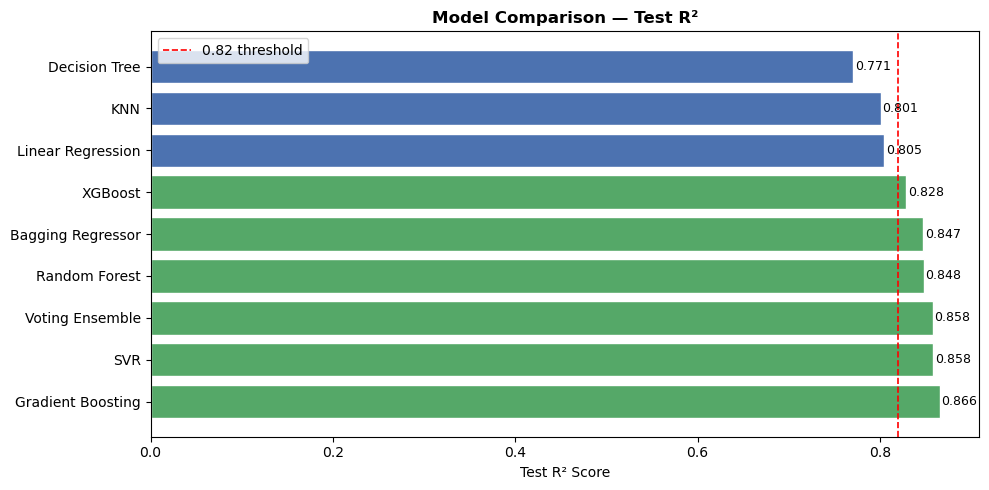

In [34]:
plt.figure(figsize=(10, 5))
colors = ['#55A868' if v >= 0.82 else '#4C72B0' for v in models_df['Test R2']]
bars = plt.barh(models_df['Model'], models_df['Test R2'], color=colors, edgecolor='white')
plt.xlabel('Test R² Score')
plt.title('Model Comparison — Test R²', fontweight='bold')
plt.axvline(0.82, color='red', linestyle='--', linewidth=1.2, label='0.82 threshold')
plt.legend()
for bar, val in zip(bars, models_df['Test R2']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# Task 7 — Hyperparameter Tuning (Gradient Boosting)

In [46]:
# since gradient boosting performed well without overfitting, we tune it further
param_grid = {
    'n_estimators'     : [100, 200, 300],
    'learning_rate'    : [0.01, 0.1, 0.2],
    'max_depth'        : [3, 5, 7],
    'min_samples_split': [2, 5, 10]
}
gb_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5, n_jobs=-1, verbose=1
)
gb_search.fit(X_train_scaled, y_train)

best_gb     = gb_search.best_estimator_
best_params = gb_search.best_params_
print("Best Hyperparameters:", best_params)

gb_results = evaluate_model(
    "Gradient Boosting (Tuned)", best_gb,
    X_train_scaled, X_test_scaled, y_train, y_test
)
print(f"\nTrain R2: {gb_results['Train R2']:.4f}")
print(f"Test  R2: {gb_results['Test R2']:.4f}")
print(f"Overfit : {gb_results['Overfitting']}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Hyperparameters: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 300}

Train R2: 0.8385
Test  R2: 0.8562
Overfit : N


In [47]:
# feature importance
feature_importances = best_gb.feature_importances_
importance_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)
print(importance_df)

            Feature  Importance
0            smoker    0.516310
1               age    0.405292
2               bmi    0.037635
3          children    0.035589
4               sex    0.003220
5  region_southwest    0.001803
6  region_northwest    0.000116
7  region_southeast    0.000034


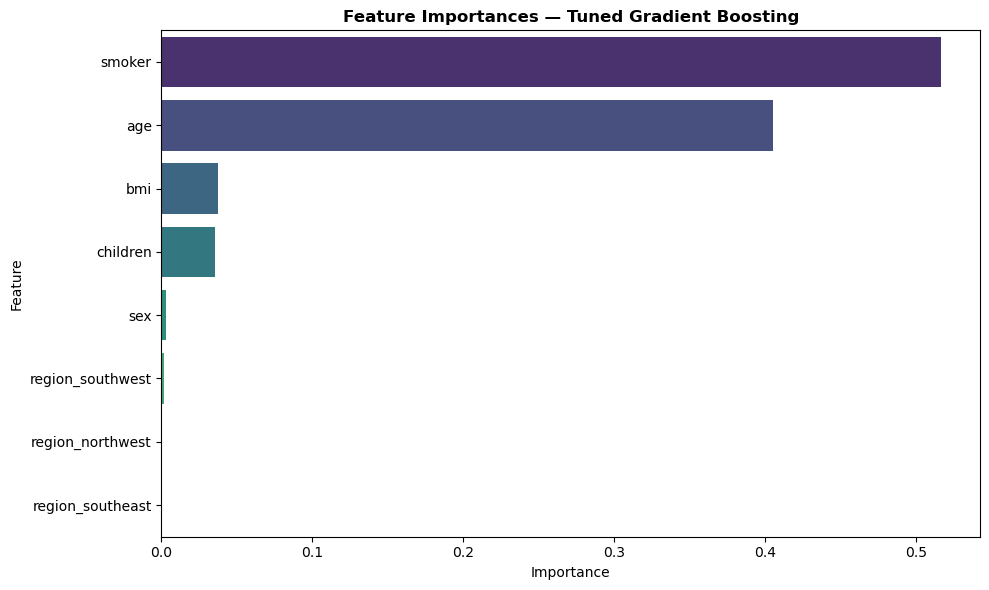

In [48]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importances — Tuned Gradient Boosting', fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Task 8 — Final Model Comparison Table

In [49]:
# add tuned model to comparison
tuned_row = {k: v for k, v in gb_results.items() if k != '_model'}
final_df  = pd.concat(
    [models_df, pd.DataFrame([tuned_row])],
    ignore_index=True
).sort_values('Test R2', ascending=False).reset_index(drop=True)

# print the required table
print("=" * 88)
print(f"{'Model':<30} {'Train RMSE':>12} {'Test RMSE':>12} {'Train R2':>10} {'Test R2':>10} {'Overfit':>8}")
print("-" * 88)
for _, row in final_df[['Model','Train RMSE','Test RMSE','Train R2','Test R2','Overfitting']].iterrows():
    flag = "⚠️  Y" if row['Overfitting'] == 'Y' else "✅  N"
    print(f"{row['Model']:<30} {row['Train RMSE']:>12.4f} {row['Test RMSE']:>12.4f} {row['Train R2']:>10.4f} {row['Test R2']:>10.4f} {flag:>8}")
print("=" * 88)

Model                            Train RMSE    Test RMSE   Train R2    Test R2  Overfit
----------------------------------------------------------------------------------------
Gradient Boosting                    0.3198       0.3477     0.8768     0.8655     ✅  N
SVR                                  0.3703       0.3568     0.8347     0.8584     ✅  N
Voting Ensemble                      0.2286       0.3578     0.9370     0.8576     ✅  N
Gradient Boosting (Tuned)            0.3661       0.3595     0.8385     0.8562     ✅  N
Random Forest                        0.1648       0.3700     0.9673     0.8477    ⚠️  Y
Bagging Regressor                    0.1675       0.3706     0.9662     0.8472    ⚠️  Y
XGBoost                              0.0892       0.3927     0.9904     0.8284    ⚠️  Y
Linear Regression                    0.4489       0.4189     0.7572     0.8047     ✅  N
KNN                                  0.3483       0.4233     0.8539     0.8006     ✅  N
Decision Tree                  

# Task 9 — Save Model as .pkl


In [50]:
# ── FIXED: save model + scaler + metadata together ──
model_bundle = {
    'model'         : best_gb,           # trained Gradient Boosting model
    'scaler'        : scaler,            # ✅ ADDED — was missing before, caused Streamlit crash
    'feature_names' : X.columns.tolist(),
    'log_transform' : 'log1p',           # ✅ DOCUMENTED — reverse with np.expm1() in app
    'model_name'    : 'Gradient Boosting (Tuned)',
    'test_r2'       : round(gb_results['Test R2'], 4),
}

with open('insurance_model.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print("✅ insurance_model.pkl saved successfully!")
print(f"   Keys saved: {list(model_bundle.keys())}")
print(f"   Features  : {model_bundle['feature_names']}")
print(f"   Test R²   : {model_bundle['test_r2']}")

✅ insurance_model.pkl saved successfully!
   Keys saved: ['model', 'scaler', 'feature_names', 'log_transform', 'model_name', 'test_r2']
   Features  : ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']
   Test R²   : 0.8562


In [52]:
# ── Verify: reload and run a test prediction ──
with open('insurance_model.pkl', 'rb') as f:
    loaded = pickle.load(f)

print("Keys in loaded bundle:", list(loaded.keys()))
print("Scaler type:", type(loaded['scaler']))
print("Model type :", type(loaded['model']))

# Test prediction — 30yr female, BMI 27, non-smoker, 1 child, northeast
test_input = np.array([[30, 1, 27.0, 1, 0, 0, 0, 0]])   # female=1, no=0, northeast → all region flags 0
test_scaled = loaded['scaler'].transform(test_input)
log_pred    = loaded['model'].predict(test_scaled)[0]
predicted   = np.expm1(log_pred)    # reverse log1p with expm1

print(f"\nSample prediction (30F, BMI 27, non-smoker, 1 child, NE): ${predicted:,.2f}")
print("\n✅ Bundle verified — scaler and model both working correctly!")

Keys in loaded bundle: ['model', 'scaler', 'feature_names', 'log_transform', 'model_name', 'test_r2']
Scaler type: <class 'sklearn.preprocessing._data.StandardScaler'>
Model type : <class 'sklearn.ensemble._gb.GradientBoostingRegressor'>

Sample prediction (30F, BMI 27, non-smoker, 1 child, NE): $4,958.20

✅ Bundle verified — scaler and model both working correctly!
